# Customer Personality Prediction

### Life cycle of Machine learning Project

1] Understanding the Problem Statement
2] Data Collection
3] Data Cleaning
4] Exploratory data analysis
5] Data Pre-Processing
6] Model Training
7] Choose best model

1) Problem statement.

1] xyz company wants to enable and establish a viable business model to expand the customer base.
2] One of the ways to expand the customer base is to introduce a new offering of packages based on the customer personalities.
3] The company wants to segregate the customers so that they can release relevant offers for the respective customers


### What is Customer personality analysis and segmentation?
Customer Personality Analysis is a detailed analysis of a company’s ideal customers. It helps a business to better understand its customers and makes it easier for them to modify products according to the specific needs, behaviors and concerns of different types of customers.

Customer personality analysis helps a business to modify its product based on its target customers from different types of customer segments. For example, instead of spending money to market a new product to every customer in the company’s database, a company can analyze which customer segment is most likely to buy the product and then market the product only on that particular segment.

2. Data Collection
The dataset is downloaded from https://github.com/entbappy/Branching-tutorial/blob/master/marketing_campaign.zip
2.1 Import Data and Required Packages
Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
# importing all neccssary libraries here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as pe
import warnings
import copy
from datetime import datetime
from statsmodels.stats.outliers_influence import variance_inflation_factor
warnings.filterwarnings('ignore')

### loading the data 


In [2]:
df = pd.read_csv('marketing_campaign.csv',sep='\t')

In [3]:
#copy of data set
df_copy =copy.deepcopy(df)

### data understanding

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df.shape

(2240, 29)

In [6]:
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [7]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [8]:
df.isnull().sum()
# Income                 24

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [10]:
df['Dt_Customer']

0       04-09-2012
1       08-03-2014
2       21-08-2013
3       10-02-2014
4       19-01-2014
           ...    
2235    13-06-2013
2236    10-06-2014
2237    25-01-2014
2238    24-01-2014
2239    15-10-2012
Name: Dt_Customer, Length: 2240, dtype: object

In [11]:
# formatting Dt_customer into proper date time 
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'],format='%d-%m-%Y')

In [12]:
df['Dt_Customer'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2240 entries, 0 to 2239
Series name: Dt_Customer
Non-Null Count  Dtype         
--------------  -----         
2240 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 17.6 KB


In [13]:
# dropping ID column 
# and seprating catgorical and numerical columns
column = [id for id in df.columns if id!='ID']
num_col = [cat for cat in column if df[cat].dtype !='object']
cat_col= [num for num in column if df[num].dtype =='object']
print(f'we have {len(cat_col)} categorical columns and they are \n\n{cat_col}\n\n and we have {len(num_col)} numerical column and they are \n\n{num_col}')

we have 2 categorical columns and they are 

['Education', 'Marital_Status']

 and we have 26 numerical column and they are 

['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


In [14]:
cat_col

['Education', 'Marital_Status']

In [15]:
num_col

['Year_Birth',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Z_CostContact',
 'Z_Revenue',
 'Response']

In [16]:
df[cat_col]

,Education,Marital_Status
0,Graduation,Single
1,Graduation,Single
2,Graduation,Together
3,Graduation,Together
4,PhD,Married
...,...,...
2235,Graduation,Married
2236,PhD,Together
2237,Graduation,Divorced
2238,Master,Together


In [17]:
df[num_col]

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,1957,58138.0,0,0,2012-09-04,58,635,88,546,172,...,7,0,0,0,0,0,0,3,11,1
1,1954,46344.0,1,1,2014-03-08,38,11,1,6,2,...,5,0,0,0,0,0,0,3,11,0
2,1965,71613.0,0,0,2013-08-21,26,426,49,127,111,...,4,0,0,0,0,0,0,3,11,0
3,1984,26646.0,1,0,2014-02-10,26,11,4,20,10,...,6,0,0,0,0,0,0,3,11,0
4,1981,58293.0,1,0,2014-01-19,94,173,43,118,46,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,61223.0,0,1,2013-06-13,46,709,43,182,42,...,5,0,0,0,0,0,0,3,11,0
2236,1946,64014.0,2,1,2014-06-10,56,406,0,30,0,...,7,0,0,0,1,0,0,3,11,0
2237,1981,56981.0,0,0,2014-01-25,91,908,48,217,32,...,6,0,1,0,0,0,0,3,11,0
2238,1956,69245.0,0,1,2014-01-24,8,428,30,214,80,...,3,0,0,0,0,0,0,3,11,0


In [18]:
df[cat_col].value_counts().count()

np.int64(31)

In [19]:
# checking how much percentage of differnt groups 
for i in cat_col:
    print(df[i].value_counts(normalize=True)*100)
    print('................................................................')

Education
Graduation    50.312500
PhD           21.696429
Master        16.517857
2n Cycle       9.062500
Basic          2.410714
Name: proportion, dtype: float64
................................................................
Marital_Status
Married     38.571429
Together    25.892857
Single      21.428571
Divorced    10.357143
Widow        3.437500
Alone        0.133929
Absurd       0.089286
YOLO         0.089286
Name: proportion, dtype: float64
................................................................


## univariate analysis
Univariate analysis is the simplest form of analyzing data. "Uni" means one, meaning the data contains only a single variable. Its primary purpose is to describe the data, summarize it, and find patterns hidden within it, without looking for causes or relationships

### numeric feature

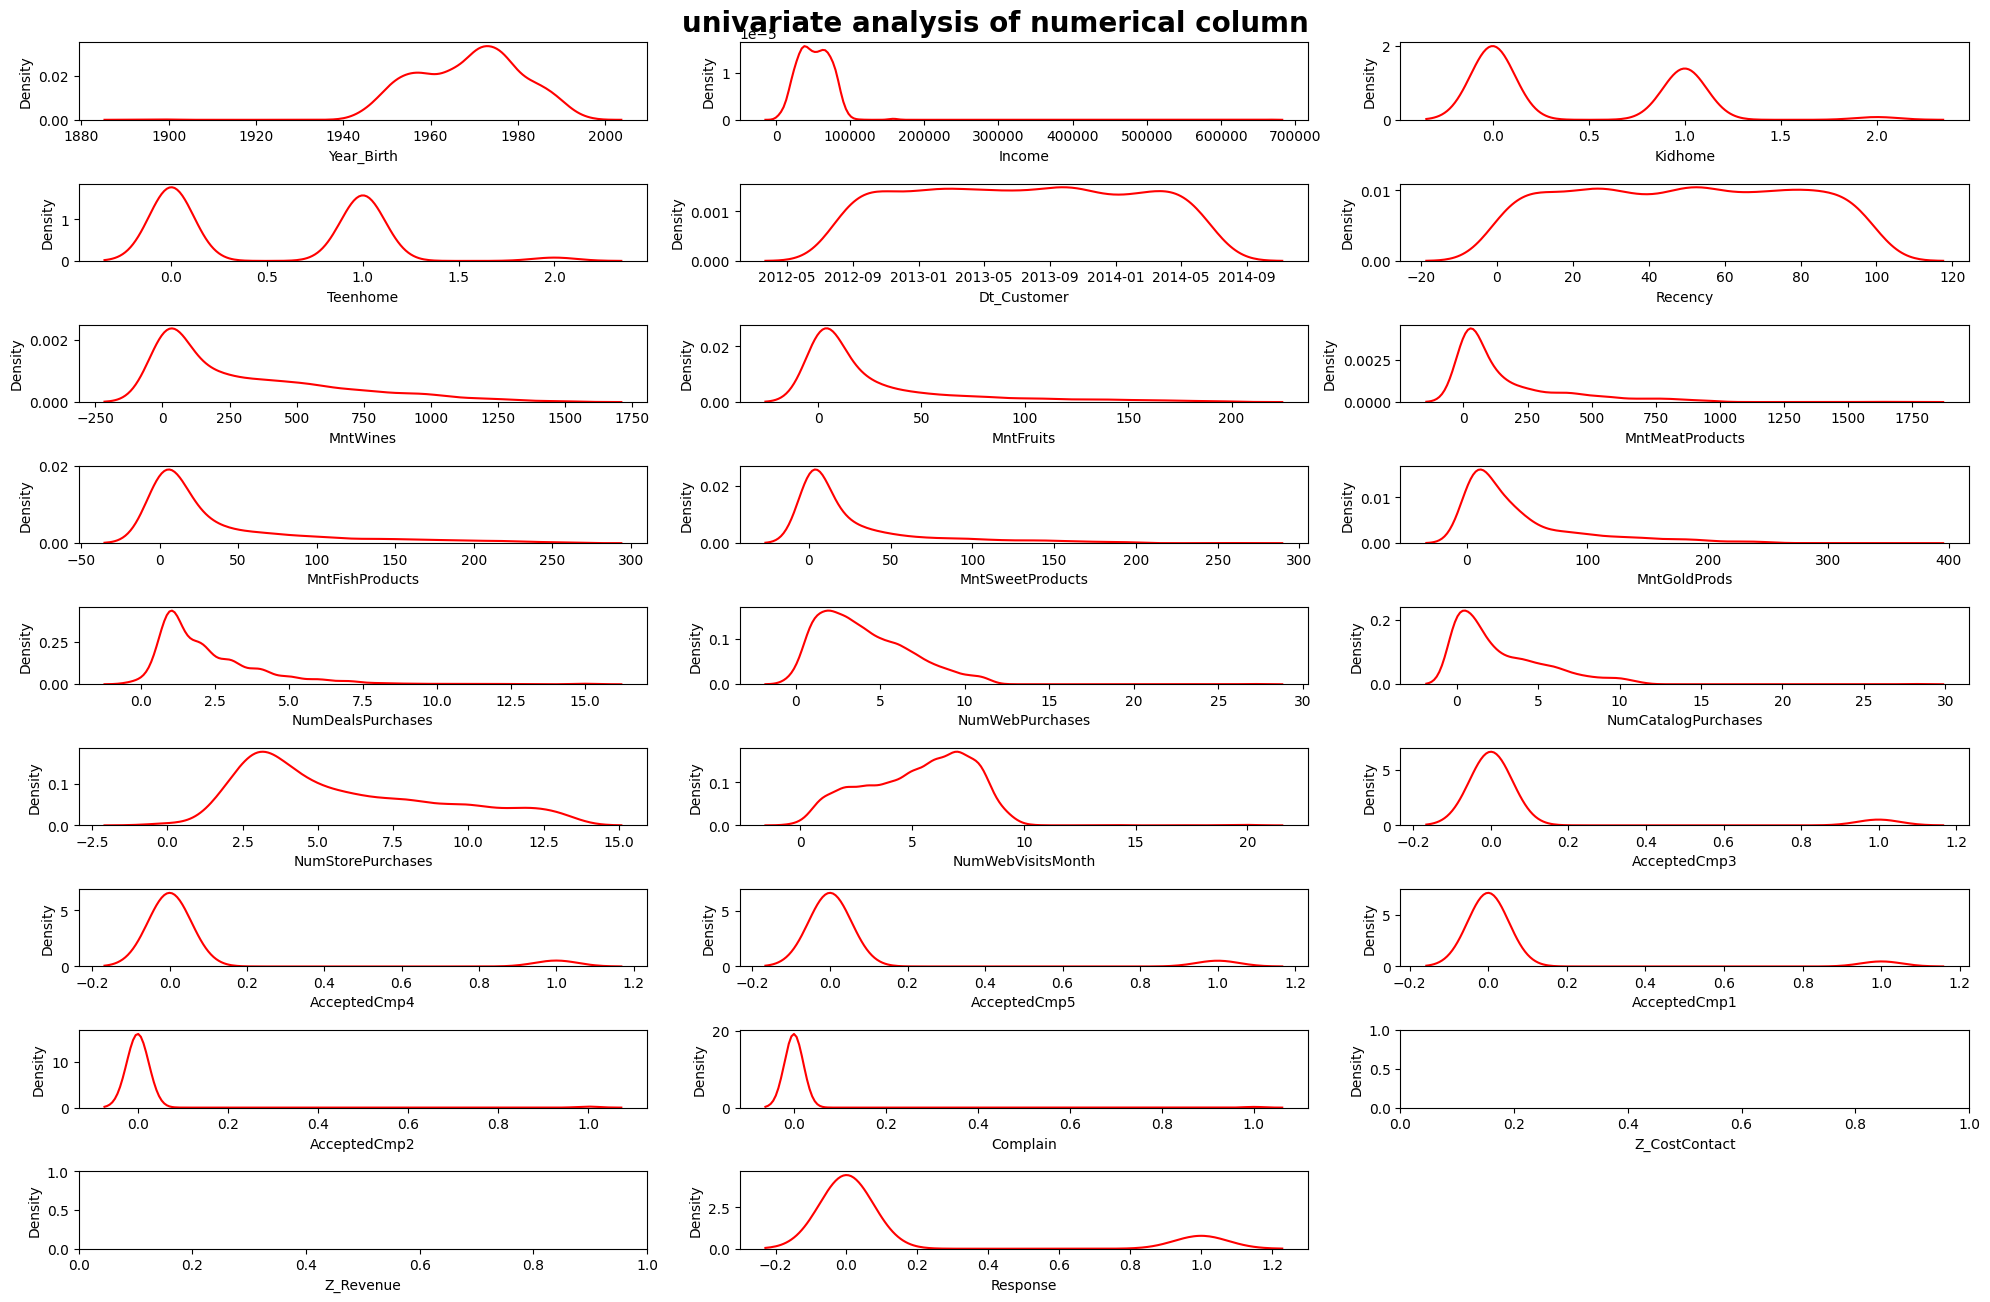

In [20]:
plt.figure(figsize=(20,20))
plt.suptitle('univariate analysis of numerical column',fontsize=20,fontweight='bold')
for j in range(0,len(num_col)):
    plt.subplot(14,3,j+1)
    sns.kdeplot(x=df[num_col[j]],color='red')
    plt.xlabel(num_col[j])
    plt.tight_layout()
# plt.show()

### Report of the univariate analytis

Year_Birth is left-skewed, most of the values falls in 1940-2000 range and has outliers.

Income is right-skewed, most of the values falls in 0 - <200000 range and has outliers.

Kidhome, Teenhome has constant values. Most of the values seems to be 0 or 1 and some of the values are 2.

Dt_customer, Recency are following a normal distribution

MntWines, MntMeatProducts are right-skewed, most of the values falls in 0 - 500 range and has outliers.

MntFruits, MntFishProducts, MntSweetProducts, MntGoldProds is right-skewed, most of the values falls in 0-50 range and has outliers.

NumDealsPurchases is right-skewed, most of the values falls in 0-5 range and has outliers.

NumWebPurchases, NumCatalogPurchases are right skewed and most of the values falls in 0-10 range and have outliers.

NumStorePurchases is almost following a normal distribution and most of the values falls in 1 - 10 range and has outliers.

NumWebVisitsMonth is right-skewed, most of the values falls in 0- 10 range and has outliers.

AcceptedCmp3, AcceptedCmp4, AcceptedCmp5, AcceptedCmp1,AcceptedCmp2 is right skewed and most of the values are 0 and some of the values are 1.

Complain has most of the values as 0 and we can see a little bit of the values as 1.

Z_CostContact, Z_Revenue columns are not showing any graph. We'll graph those seperately and check what is happening.

Response has constant values as 0 and 1.

<Axes: >

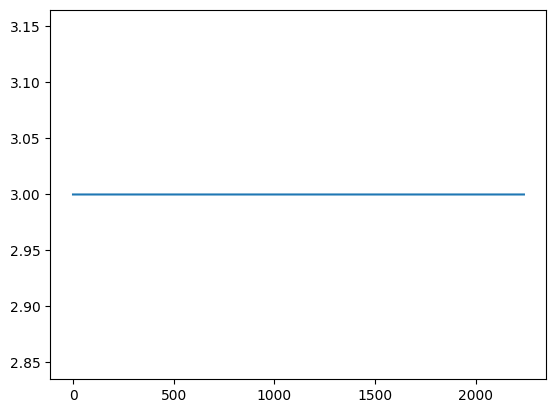

In [21]:
df['Z_CostContact'].plot()

<Axes: >

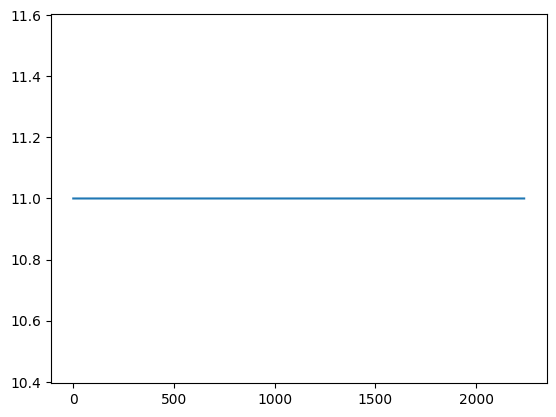

In [22]:
df['Z_Revenue'].plot()

### As we can see

The column Z_CostContact, Z_Revenue does have constant values. As this columns does not have any varience, we can drop this column

In [23]:
df.drop(columns=['Z_CostContact', 'Z_Revenue'], inplace=True)

In [24]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,0,0,0,0,0


### categorical column

Text(0.5, 0, 'Marital_Status')

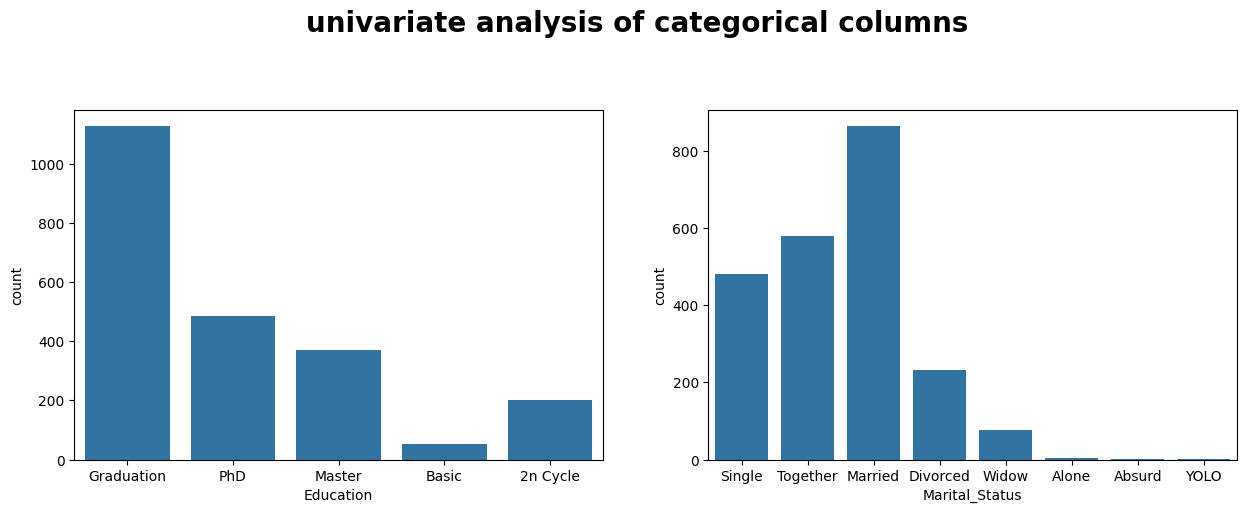

In [25]:
plt.figure(figsize=(15,10))
plt.suptitle('univariate analysis of categorical columns',fontsize=20,fontweight='bold')
for k in range(0,len(cat_col)):
    plt.subplot(2,2,k+1)
    sns.countplot(x=df[cat_col[k]])
plt.xlabel(cat_col[k])

# Report

### For column Education

Most of the Customers are falling into Graduation category.
Respectively, PhD, Master Education, Basic and *2n Cycle are also present.
2nCycle - Multidisciplinary degree programmes are second cycle degree programmes in which the teaching system meets the requirements of two different classes

### For column Maritial_Status

For about 864 customers are married.
Together, single, divorced, widow are noticeable where Alone, Absurd and YOLO categories are very less.
Count of features based on years

<Axes: xlabel='year', ylabel='count'>

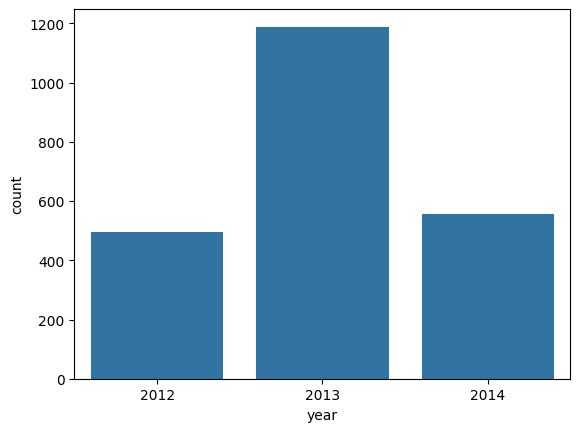

In [26]:
df1=df.copy()
df1['year']=df['Dt_Customer'].dt.year
distributin_by_year = df1.groupby(by='year',axis =0)['ID'].count()
distributin_by_year = distributin_by_year.reset_index()
distributin_by_year.columns = ['year','count']
sns.barplot(data=distributin_by_year,x=distributin_by_year['year'],y=distributin_by_year['count'])

# Report

By this report, we can say that, most number of customers have joined in the year 2013
The number of customers got increased in year 2013 but in the year 2014, the number of customers got decreased.


# Multivariate Analysis
Multivariate analysis (MVA) is a set of statistical techniques used to analyze datasets containing more than one variable. By examining multiple variables simultaneously, MVA uncovers hidden patterns, identifies complex correlations

### checking multicollinearity in numerical features

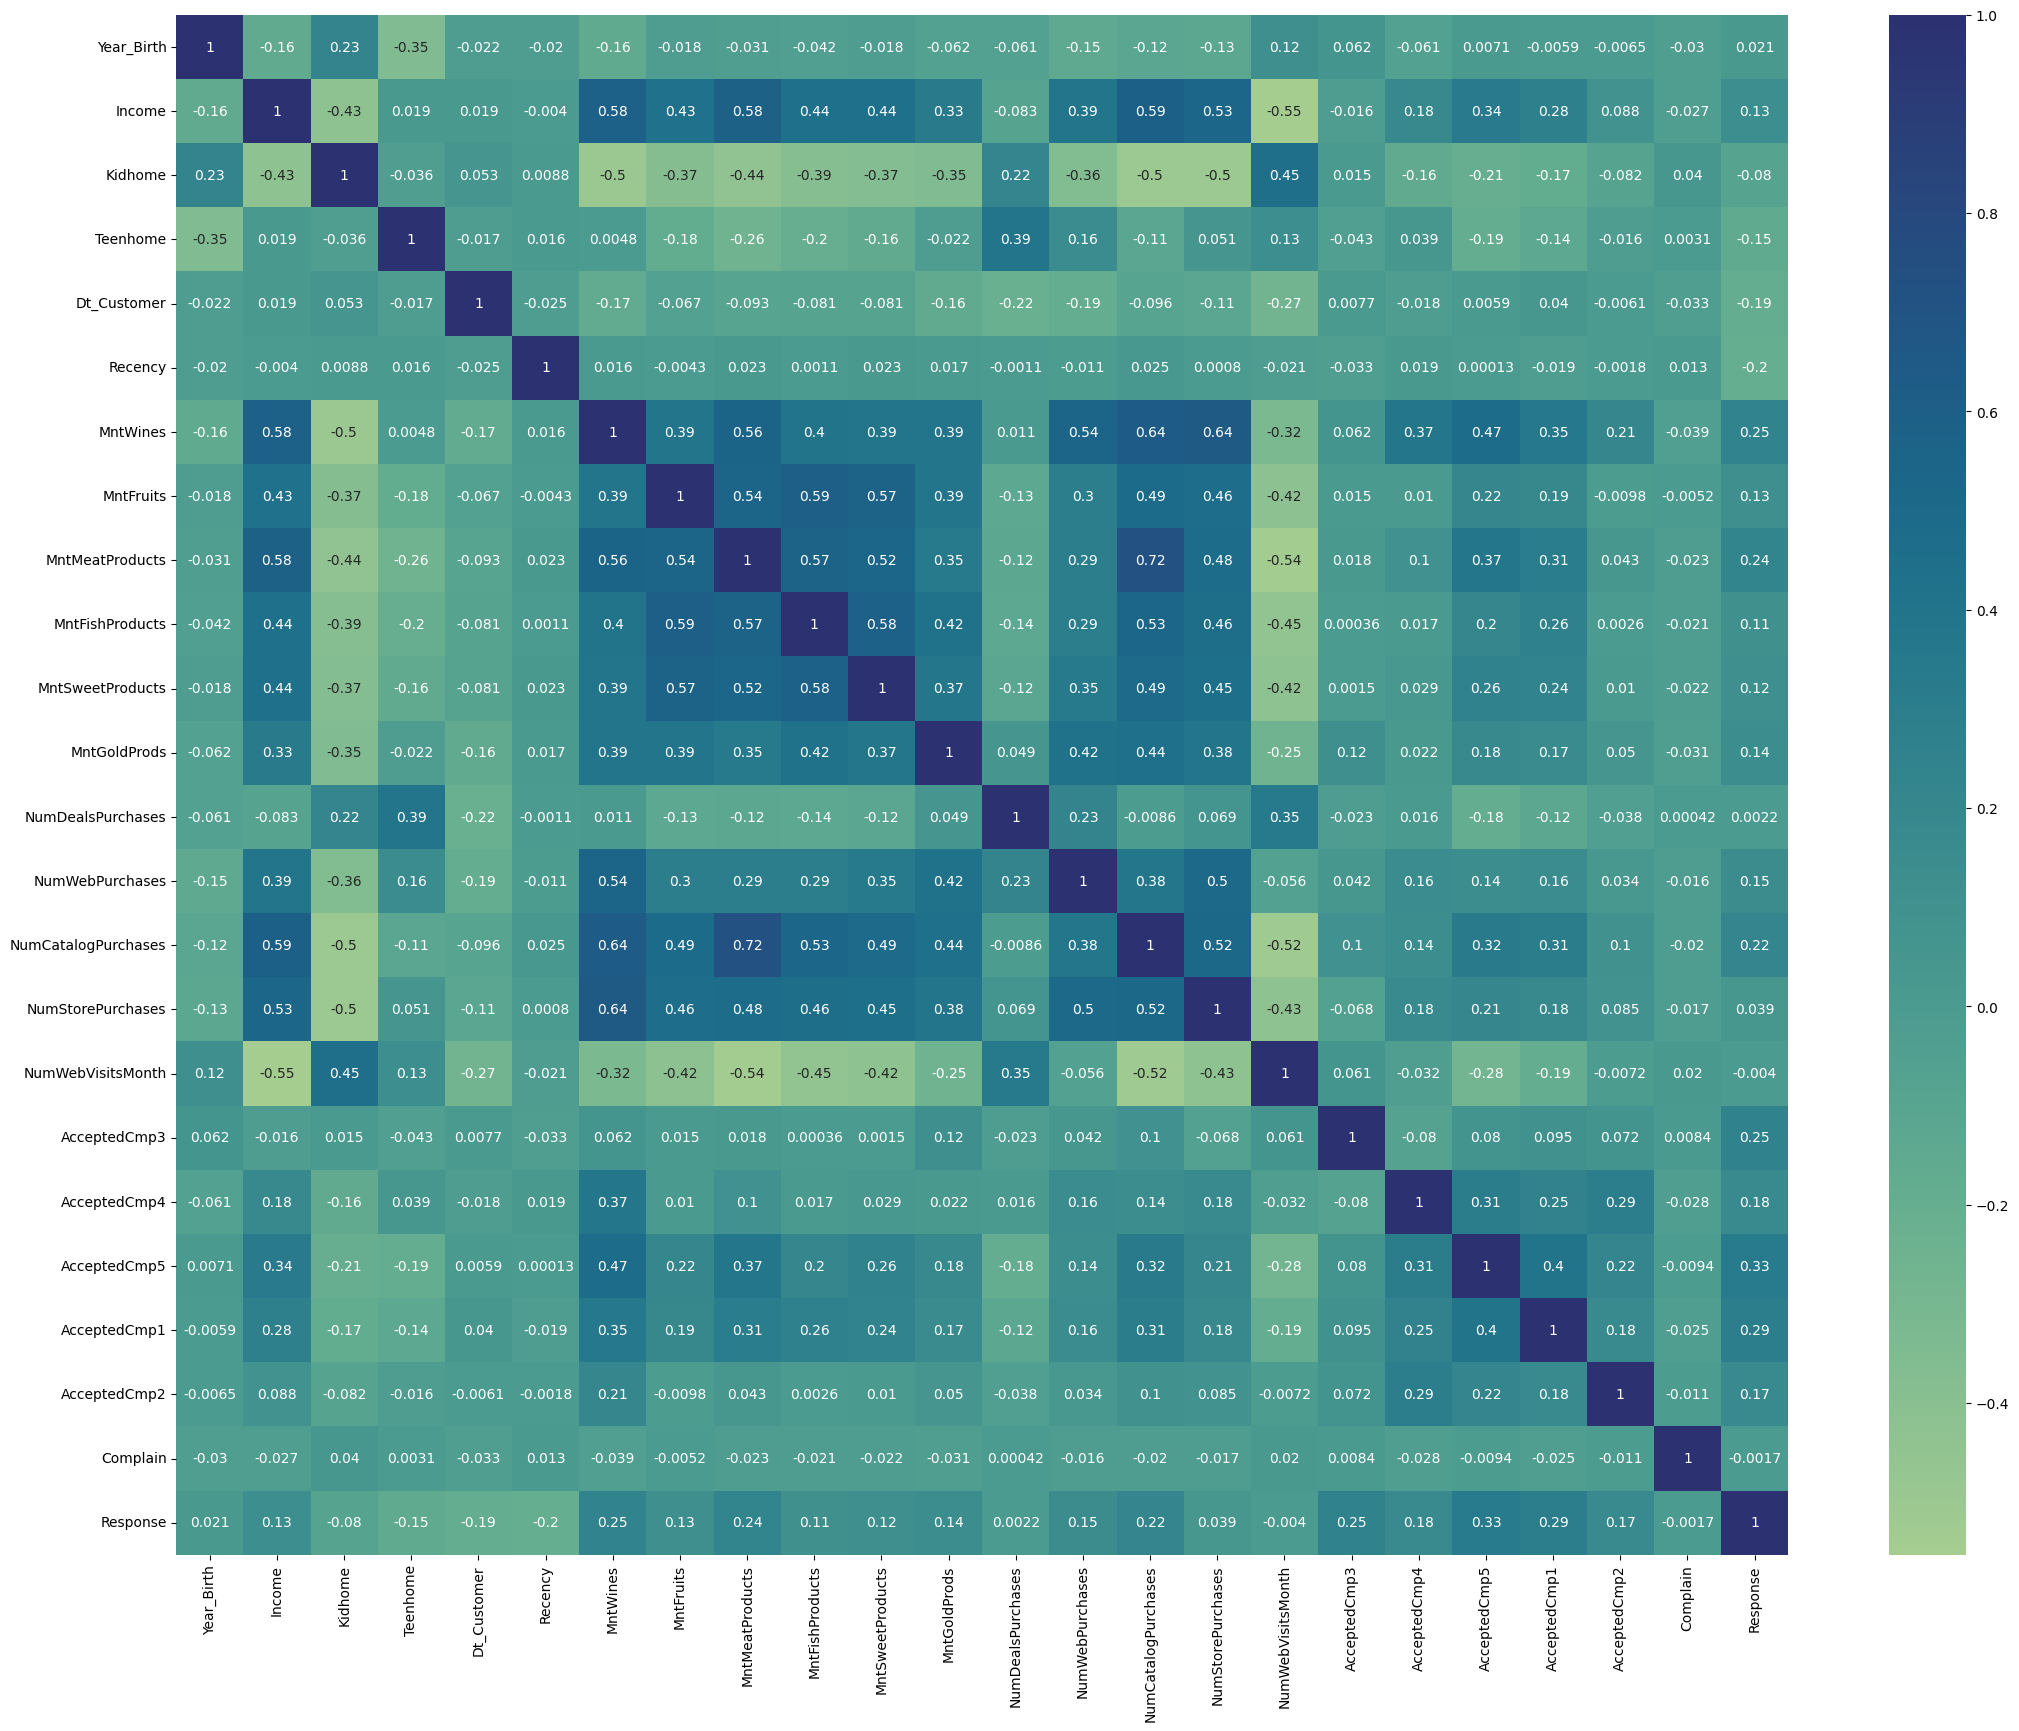

In [27]:
num_col.remove('Z_CostContact')
num_col.remove('Z_Revenue')
plt.figure(figsize=(26,20))
sns.heatmap(df[num_col].corr(),annot=True,cmap='crest')
plt.show()

We can see that income does has some null values. Let's first input those values

In [28]:
df['Income'].fillna(df['Income'].median(),inplace=True)

In [29]:
# no missin values
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
dtype: int64

# Feature extraction

In [30]:
len(df.columns)

27

In [31]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response'],
      dtype='object')

In [32]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,0,0,0,0,0


In [33]:
df['age']= 2026-df['Year_Birth']

In [34]:
df['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [35]:
df['Education'].replace({'Graduation':0,'PhD':1,'Master':2,'Basic':3,'2n Cycle':4},inplace=True)

In [36]:
df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [37]:
df['Marital_Status'].replace({'Single':0,'Together':1,'Married':1,'Divorced':0,'Widow':0,'Alone':0,'Absurd':0,'YOLO':0},inplace=True)

In [38]:
df['children'] = df['Kidhome']+df['Teenhome']
df['family size']=df['Marital_Status']+df['children']+1
df['purchase amount']=df['MntFishProducts']+df['MntFruits']+df['MntGoldProds']+df['MntMeatProducts']+df['MntWines']

In [39]:
today_date = datetime.today()
df['days as customer']= (today_date-df['Dt_Customer']).dt.days
df['offers responded to']=df['AcceptedCmp1']+df['AcceptedCmp2']+df['AcceptedCmp3']+df['AcceptedCmp4']+df['AcceptedCmp5']+df['Response']

In [40]:
df["Parental Status"] = np.where(df["children"] > 0, 1, 0)
df.rename(columns={'Parental Status':'parental status'},inplace=True)

In [41]:
drop_col = ['Year_Birth','Kidhome','Teenhome']
df.drop(columns=drop_col, inplace=True)
df.rename(columns={'Marital_Status':'marital status','MntWines':'wines','MntFruits':'fruits','MntMeatProducts':'meat','MntFishProducts':'fish','MntSweetProducts':'sweet','MntGoldProds':'gold','NumWebPurchases':'web','NumCatalogPurchases':'catlog','NumStorePurchases':'store'},inplace=True)
# doubt NumDealsPurchases,Complain,family size, Response why removed
df=df[['age','Education','marital status','parental status','Income','Recency','wines','fruits','meat','fish','sweet', 'gold',
       'web', 'catlog', 'store', 'NumWebVisitsMonth', 'children',
       'purchase amount', 'days as customer', 'offers responded to']]

# df = df[["Age","Education","Marital Status","Parental Status","Children","Income","Total_Spending","Days_as_Customer",
#          "Recency","Wines","Fruits","Meat","Fish","Sweets","Gold","Web","Catalog","Store","Discount Purchases","Total Promo","NumWebVisitsMonth"]]


In [42]:
df.head()

,age,Education,marital status,parental status,Income,Recency,wines,fruits,meat,fish,sweet,gold,web,catlog,store,NumWebVisitsMonth,children,purchase amount,days as customer,offers responded to
0,69,0,0,0,58138.0,58,635,88,546,172,88,88,8,10,4,7,0,1529,5045,1
1,72,0,0,1,46344.0,38,11,1,6,2,1,6,1,1,2,5,2,26,4495,0
2,61,0,1,0,71613.0,26,426,49,127,111,21,42,8,2,10,4,0,755,4694,0
3,42,0,1,1,26646.0,26,11,4,20,10,3,5,2,0,4,6,1,50,4521,0
4,45,1,1,1,58293.0,94,173,43,118,46,27,15,5,3,6,5,1,395,4543,0


In [43]:
# df['Dt_Customer'].info()

In [44]:
df.columns

Index(['age', 'Education', 'marital status', 'parental status', 'Income',
       'Recency', 'wines', 'fruits', 'meat', 'fish', 'sweet', 'gold', 'web',
       'catlog', 'store', 'NumWebVisitsMonth', 'children', 'purchase amount',
       'days as customer', 'offers responded to'],
      dtype='object')

In [45]:
df.shape

(2240, 20)

In [46]:
column = [id for id in df.columns if id!='ID']
num_col = [cat for cat in column if df[cat].dtype !='object']
cont_col = [i for i in num_col if df[i].nunique()>10]


### Multicollinearity Check
Variance Inflation Factor (VIF)

Multicollinearity occurs when there are two or more independent variables in a multiple regression model, which have a high correlation among themselves. When some features are highly correlated.


Multicollinearity can be detected using various techniques, one such technique being the Variance Inflation Factor(VIF).

In [47]:
# doubt
def compute_vif(considered_features, df):
    
    X = df[considered_features]
    # the calculation of variance inflation requires a constant
    X['intercept'] = 1
    
    # create dataframe to store vif values
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif = vif[vif['Variable']!='intercept']
    return vif

        
#we will remove the datetime column which is not required for the vif checking
cont_col_backup = cont_col.copy()

# we will not chech vif for total spending, as it is the summation of Wines,Fruits,Meat,Fish,Sweets,Gold.
if 'Dt_Customer' in cont_col_backup:
    cont_col_backup.remove('Dt_Customer')

if 'purchase amount' in cont_col_backup:
    cont_col_backup.remove('purchase amount')
compute_vif(cont_col_backup, df)
# other_columns
# no multicollinearity

,Variable,VIF
0,age,1.070985
1,Income,2.125001
2,Recency,1.004898
3,wines,2.586162
4,fruits,1.924225
5,meat,2.755897
6,fish,2.055620
7,sweet,1.890537
8,gold,1.482035
9,web,1.822639


Most research papers consider a VIF (Variance Inflation Factor) > 10 as an indicator of multicollinearity, but some choose a more conservative threshold of 5.
**As we can see the Vif for the columns are less than 5, we can safely assume that the data has not such correlations.

In [48]:
print(cont_col)

['age', 'Income', 'Recency', 'wines', 'fruits', 'meat', 'fish', 'sweet', 'gold', 'web', 'catlog', 'store', 'NumWebVisitsMonth', 'purchase amount', 'days as customer']


In [49]:
print(df[cont_col].dtypes)

age                    int64
Income               float64
Recency                int64
wines                  int64
fruits                 int64
meat                   int64
fish                   int64
sweet                  int64
gold                   int64
web                    int64
catlog                 int64
store                  int64
NumWebVisitsMonth      int64
purchase amount        int64
days as customer       int64
dtype: object


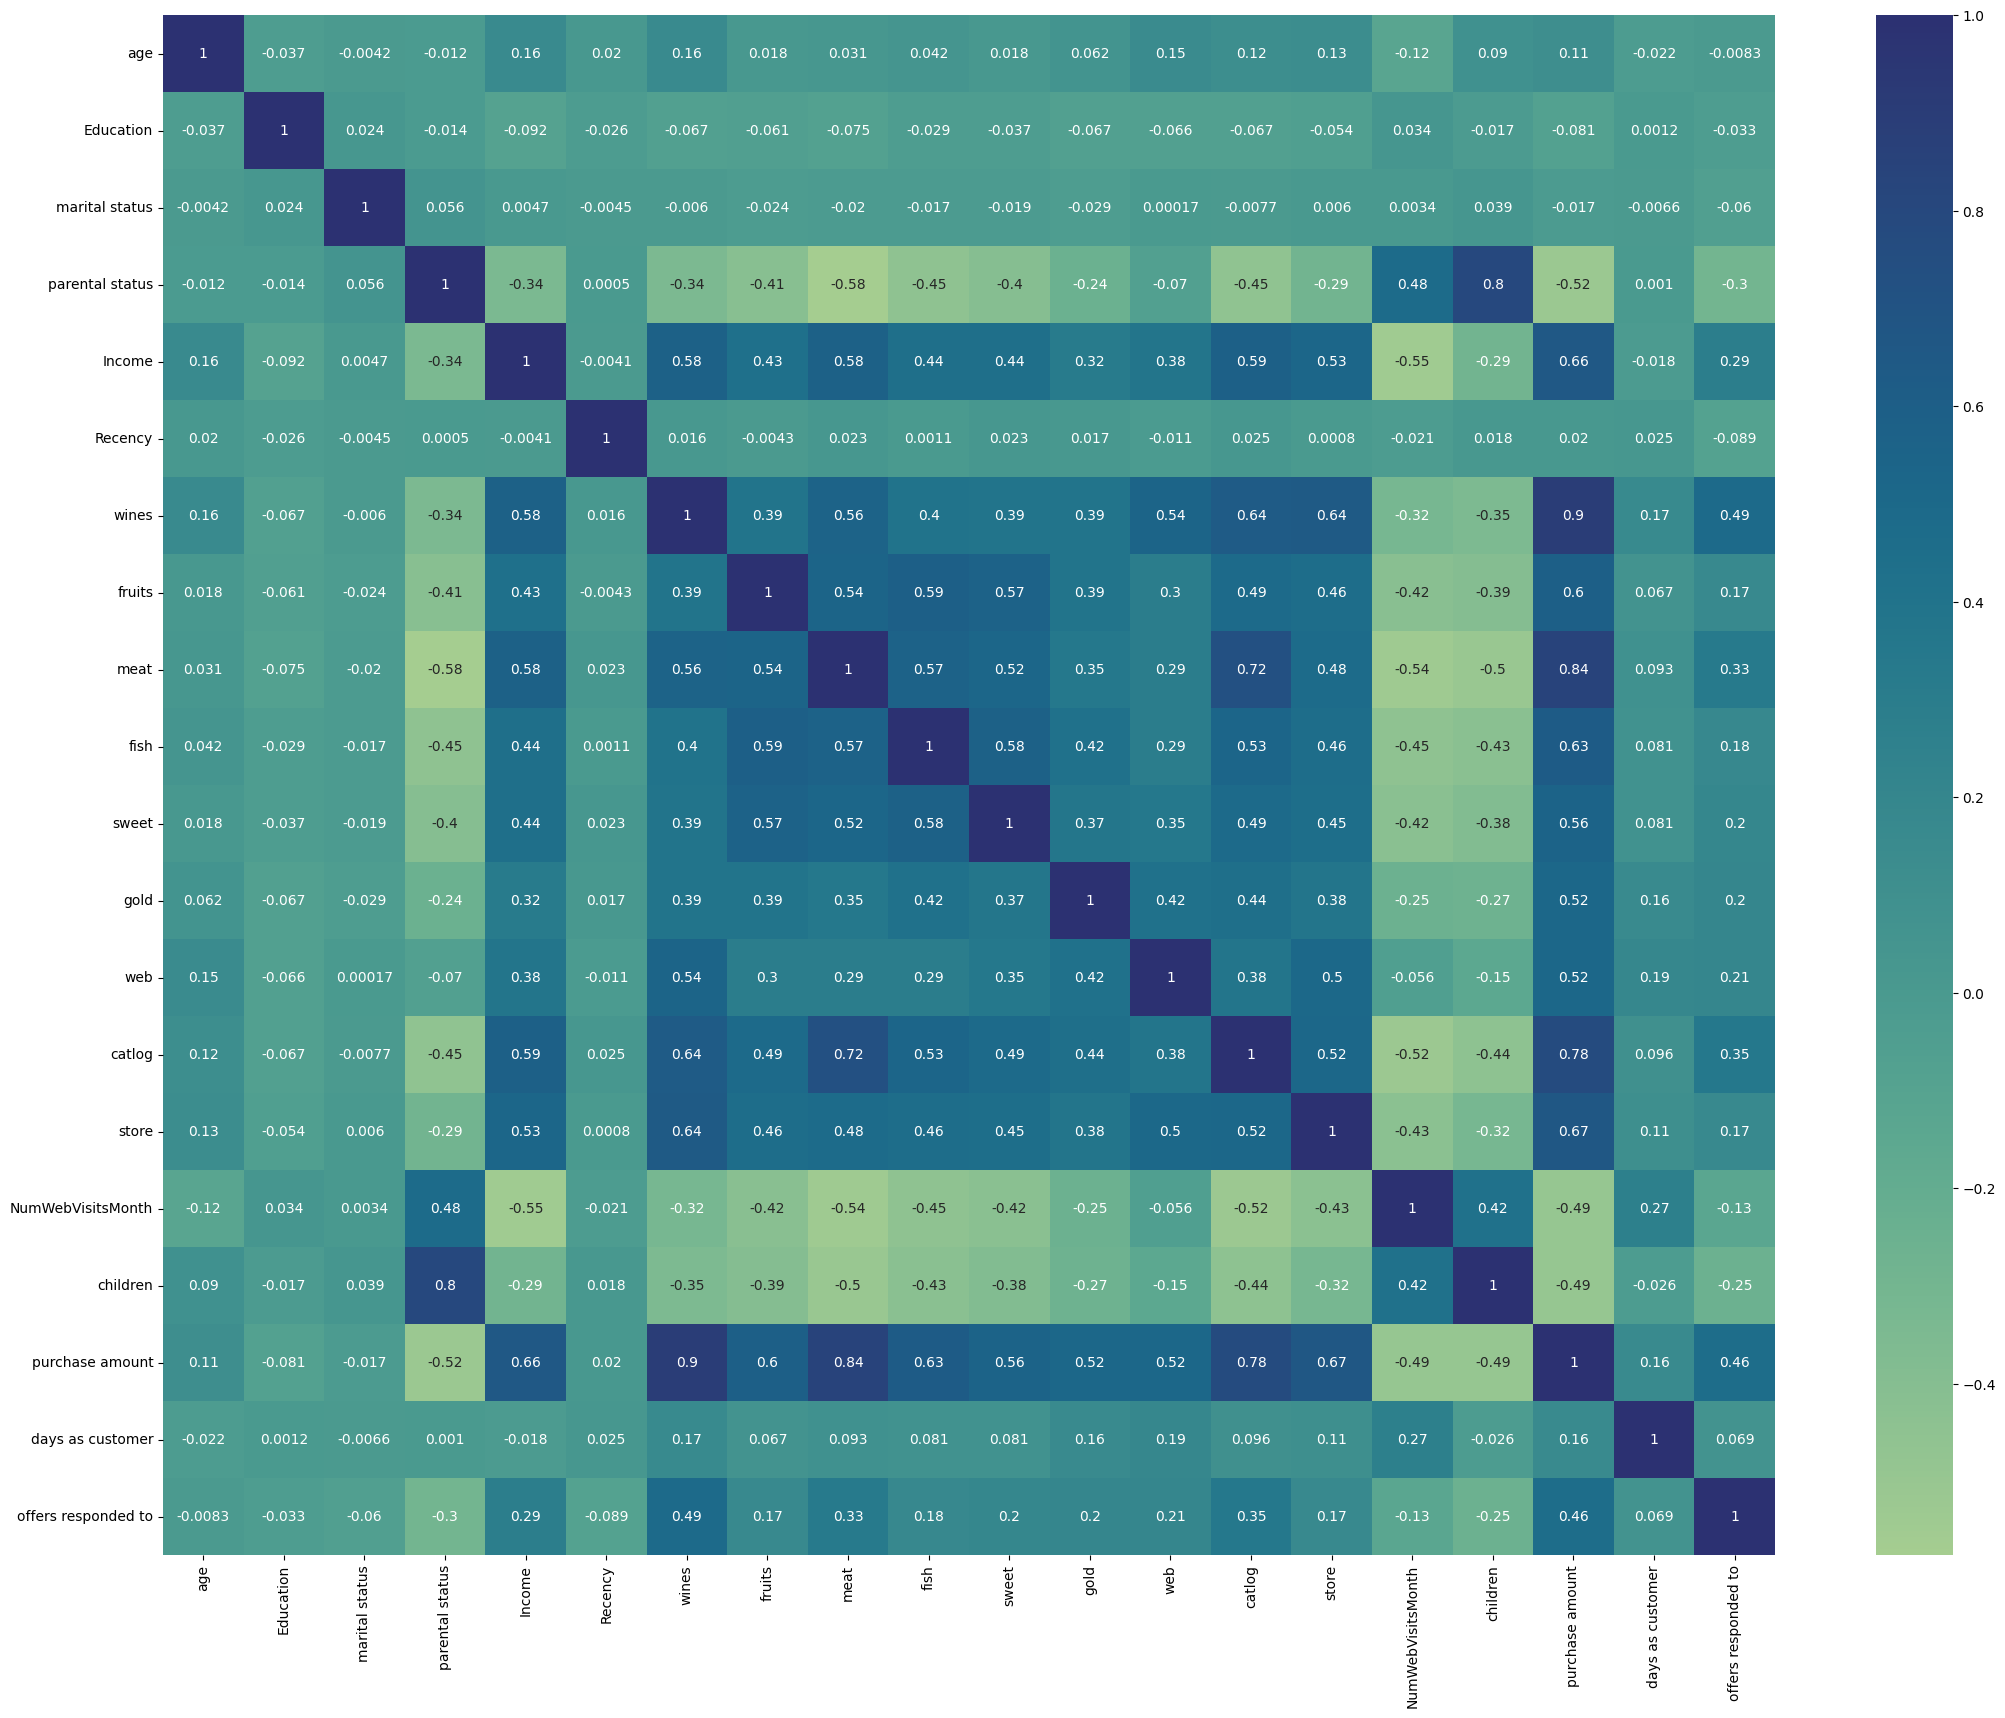

In [50]:
plt.figure(figsize=(26,20))
sns.heatmap(df[num_col].corr(),annot=True,cmap='crest')
plt.show()

In [51]:
df.isnull().sum()

age                    0
Education              0
marital status         0
parental status        0
Income                 0
Recency                0
wines                  0
fruits                 0
meat                   0
fish                   0
sweet                  0
gold                   0
web                    0
catlog                 0
store                  0
NumWebVisitsMonth      0
children               0
purchase amount        0
days as customer       0
offers responded to    0
dtype: int64

We can see there is null values in Income column, We can impute the null values in feature engineering steps.

# Initial Analysis Report
There are missing values in the Income column.


The ID column can be deleted because each row has unique values.

There is no such target feature, so we can do clustering.

# 4. Visualization
### 4.1 Do Men or Women, who are most in count?


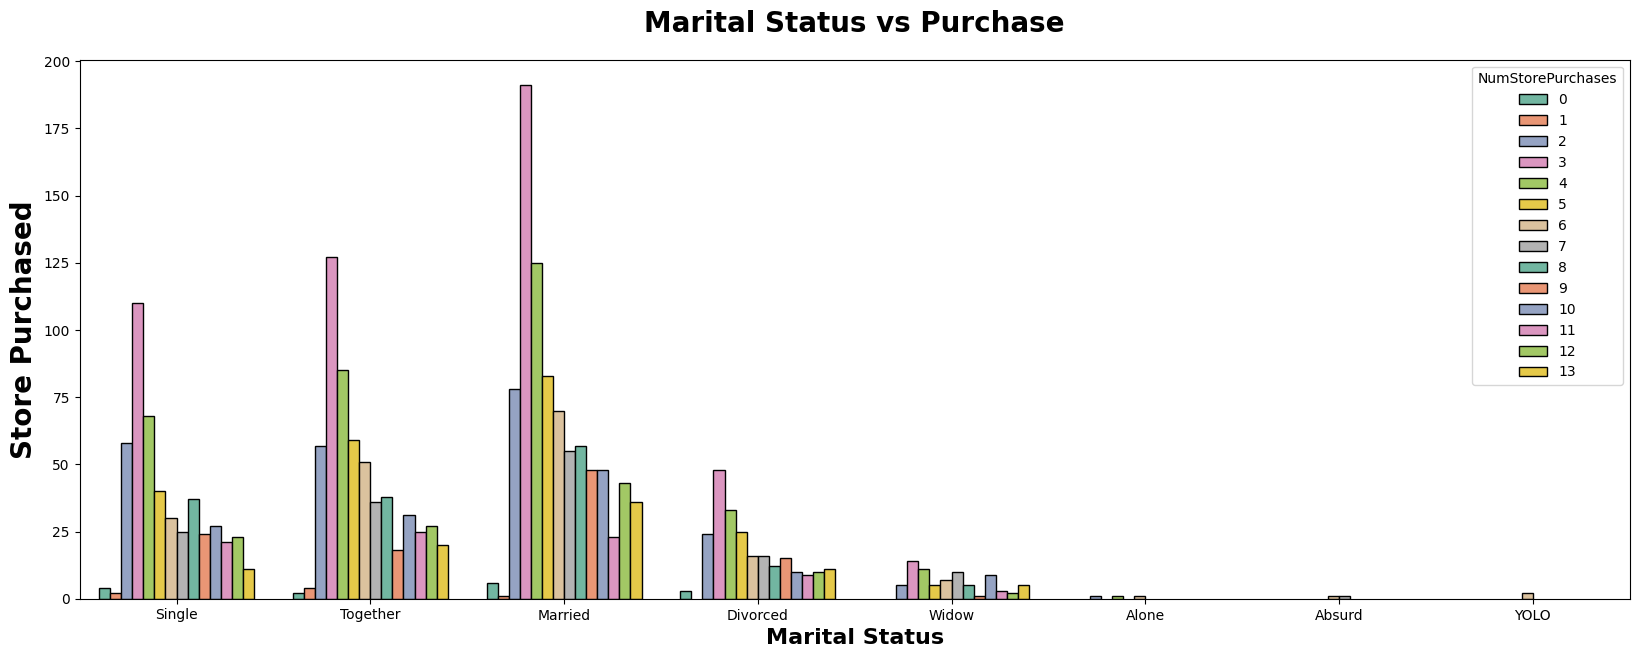

In [52]:
# doubt
plt.subplots(figsize=(20,7))
sns.countplot(x="Marital_Status",hue="NumStorePurchases", data=df1,ec = "black",palette="Set2")
plt.title("Marital Status vs Purchase", weight="bold",fontsize=20, pad=20)
plt.ylabel("Store Purchased", weight="bold", fontsize=20)
plt.xlabel("Marital Status", weight="bold", fontsize=16)
plt.show()

In [53]:
print(list(df.columns))

['age', 'Education', 'marital status', 'parental status', 'Income', 'Recency', 'wines', 'fruits', 'meat', 'fish', 'sweet', 'gold', 'web', 'catlog', 'store', 'NumWebVisitsMonth', 'children', 'purchase amount', 'days as customer', 'offers responded to']


In [54]:
dates=[]
for i in df_copy['Dt_Customer']:
    dates.append(i.date())
print(f'the first customer as on date {min(dates)}\nand the last customer is on date {max(dates)}')

AttributeError: 'str' object has no attribute 'date'

In [55]:
df.shape

(2240, 20)

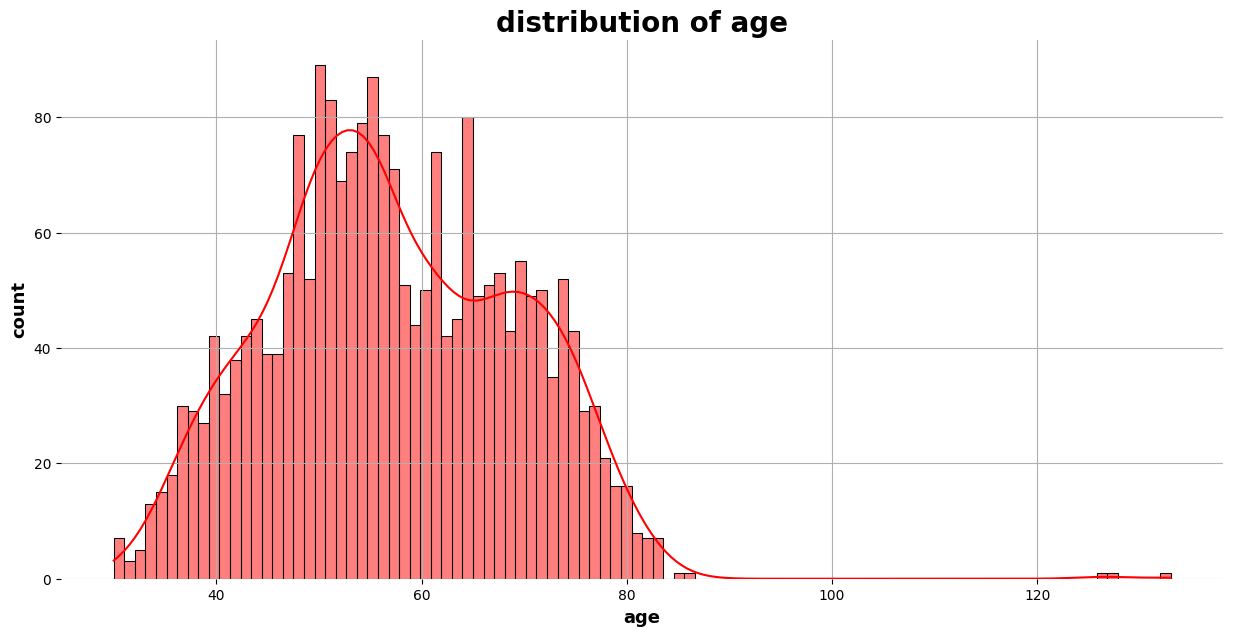

In [56]:
plt.figure(figsize=(15,7))
plt.title('distribution of age',fontsize=20,fontweight='bold')
sns.histplot(data=df,x=df['age'],kde=True,color = 'red',bins=100,palette='rocket')
plt.grid(True)
plt.xlabel('age',loc='center',fontsize=13,fontweight='bold')
plt.ylabel('count',loc='center',fontsize=13,fontweight='bold')
sns.despine(left=True,bottom=True)
plt.show()

Let's have a look again on the distribution of customer's income and spending :


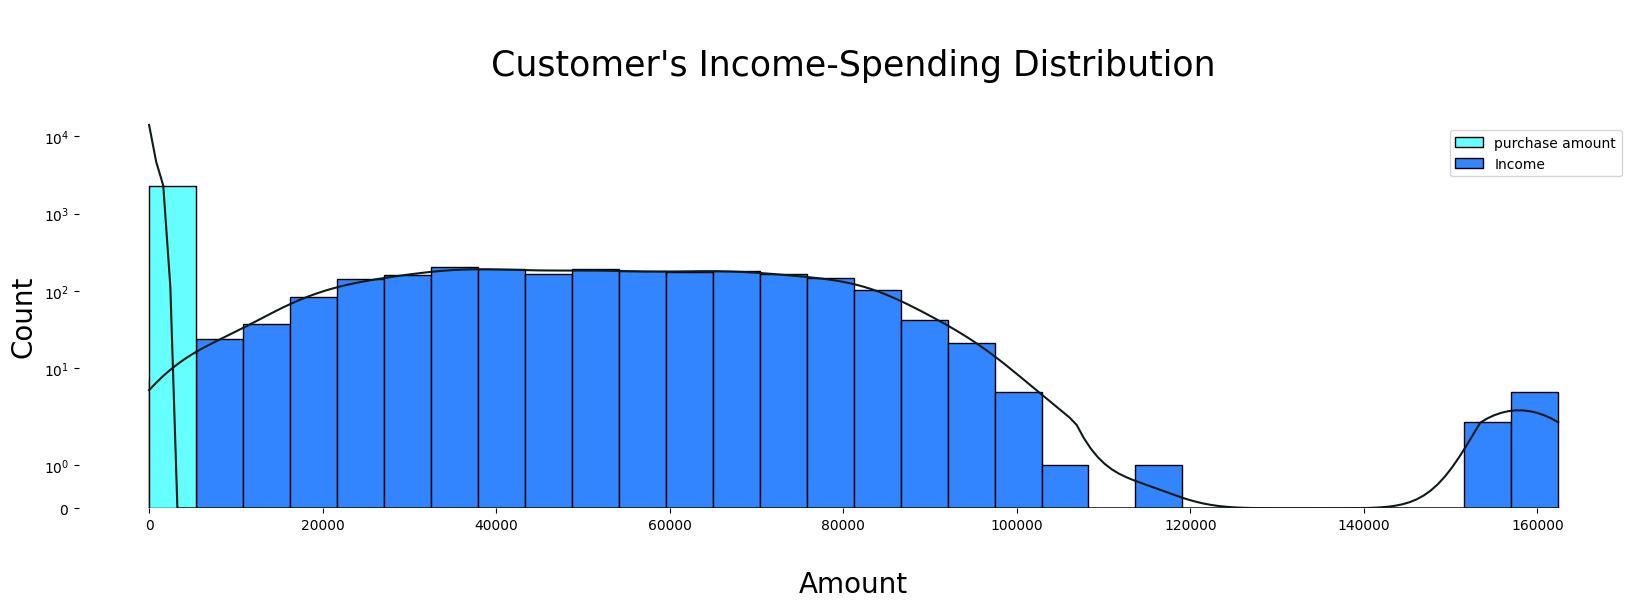

In [57]:
df = df[df["Income"] < 600000]

#now, let's plot again
print(f"Let's have a look again on the distribution of customer's income and spending :")
plt.subplots(figsize=(20, 5))
p = sns.histplot(df[["purchase amount","Income"]],palette=["#66ffff","#3385ff"],kde=True,bins=30,alpha=1,fill=True,edgecolor="black")
p.axes.lines[0].set_color("#101B15")
p.axes.lines[1].set_color("#101B15")
p.axes.set_yscale("symlog")
p.axes.set_title("\nCustomer's Income-Spending Distribution\n",fontsize=25)
plt.ylabel("Count",fontsize=20)
plt.xlabel("\nAmount",fontsize=20)
sns.despine(left=True, bottom=True)

plt.show()

Let's have a look on the customer's education :


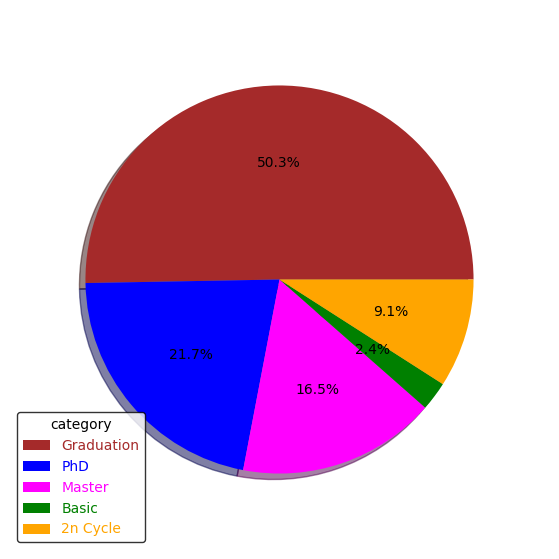

In [68]:
print(f"Let's have a look on the customer's education :")
plt.figure(figsize=(15,7))
labels = ['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
wedges,text,autotext=plt.pie([df['Education'].value_counts()[0],
                             df['Education'].value_counts()[1],
                             df['Education'].value_counts()[2],
                             df['Education'].value_counts()[3],
                             df['Education'].value_counts()[4]],
                             explode=(0,0,0,0,0),
                             colors=['brown','blue','magenta','green','orange'],
                             shadow=True,
                             radius=.9,
                            autopct='%1.1f%%')
plt.legend(wedges,labels,title='category',loc='lower left',fontsize=10,edgecolor ='black',labelcolor =['brown','blue','magenta','green','orange'])
plt.show()

Let's have a look on the distribution of customer's children :


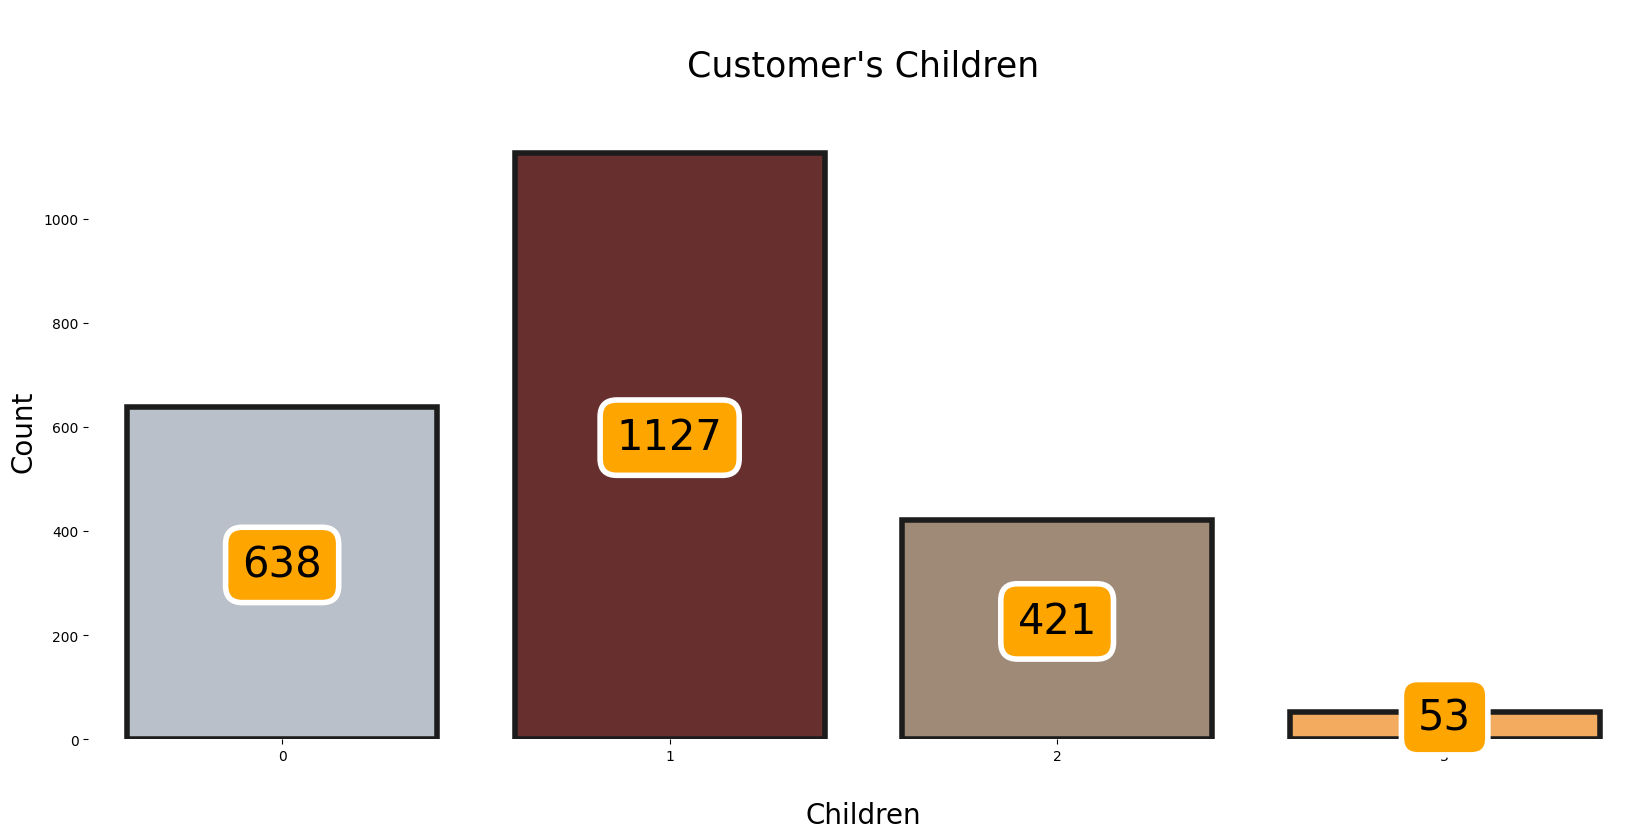

In [70]:
print(f"Let's have a look on the distribution of customer's children :")
plt.subplots(figsize=(20, 8))
p = sns.countplot(x=df["children"],palette=["#B9C0C9","#682F2F", "#9F8A78","#F3AB60"], saturation=1,edgecolor = "#1c1c1c", linewidth = 4)
p.axes.set_yscale("linear")
p.axes.set_title("\nCustomer's Children\n",fontsize=25)
p.axes.set_ylabel("Count",fontsize=20)
p.axes.set_xlabel("\nChildren",fontsize=20)
p.axes.set_xticklabels(p.get_xticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.4, "facecolor": "orange", "edgecolor": "white", "linewidth" : 4, "alpha": 1})


sns.despine(left=True, bottom=True)
plt.show()

# Report:

632 customers have no child.

Most of the customers have one child

416 customers have two child.

50 customers have three child.

# Final report
We have seen that this dataset has outliers in Wines, Fruits, Meat, Fish, Sweets, Gold, Age, Total_Spending columns and multicollinearity in Total_Spending,Wines,Fruits,Meat,Fish,Sweets,Gold columns. So we have to handle those in feature engineering steps.

We have dropped the ID column as it is not going to participate in any model building task

The column Z_CostContact, Z_Revenue does have constant values. As this columns does not have any varience, we have dropped this column

There are some columns which individually does not have such meaning, so in feature engineering we'll retrieve new columns.